### Task 1 — Data Exploration and Assumption Checks

1. Load the dataset and perform a quick EDA (shape, types, missing values, distributions).
2. For each numeric variable you plan to test, check normality (Shapiro-Wilk or Q-Q plot) and equal-variance assumptions (Levene's test).
3. Identify and document any assumption violations and state how they influence your test selection.

In [6]:
from scipy import stats
import statsmodels.api as sm
import seaborn as sns
import pandas as pd
import numpy as np

In [7]:
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zara2099/e-commerce-customer-behavior-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\zara2099\e-commerce-customer-behavior-dataset\versions\1


In [8]:
df= pd.read_csv('ecommerce_user_dataset.csv')
df

,Customer_ID,Purchase_History,Transaction_Frequency,Monetary_Value,Browsing_Behavior,Engagement_Score,Time_on_Site,Customer_Segment
0,CUST0001,23,0.257656,664.09,88.10,0.26,11.84,Iron
1,CUST0002,15,0.378479,4244.21,5.87,0.28,35.04,Copp
2,CUST0003,21,2.578130,4638.47,23.88,0.93,10.14,Copp
3,CUST0004,25,1.749848,7277.56,89.84,0.02,22.02,Iron
4,CUST0005,15,1.322330,5785.45,26.36,0.70,42.12,Copp
...,...,...,...,...,...,...,...,...
995,CUST0996,19,3.345536,6822.76,73.86,0.05,30.97,Iron
996,CUST0997,18,0.429273,9324.23,28.23,0.75,32.19,Copp
997,CUST0998,20,3.077081,9969.80,64.27,0.96,48.83,Copp
998,CUST0999,12,1.829757,7229.56,34.76,0.24,44.40,Copp


In [9]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            1000 non-null   object 
 1   Purchase_History       1000 non-null   int64  
 2   Transaction_Frequency  1000 non-null   float64
 3   Monetary_Value         1000 non-null   float64
 4   Browsing_Behavior      1000 non-null   float64
 5   Engagement_Score       1000 non-null   float64
 6   Time_on_Site           1000 non-null   float64
 7   Customer_Segment       1000 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 62.6+ KB
None


In [11]:
print(df.isnull().sum())

Customer_ID              0
Purchase_History         0
Transaction_Frequency    0
Monetary_Value           0
Browsing_Behavior        0
Engagement_Score         0
Time_on_Site             0
Customer_Segment         0
dtype: int64


In [12]:
print(df.describe())

       Purchase_History  Transaction_Frequency  Monetary_Value  \
count       1000.000000            1000.000000     1000.000000   
mean          19.886000               4.918180     4926.211670   
std            4.598712               4.880951     2819.093279   
min            7.000000               0.000058      100.300000   
25%           17.000000               1.426240     2455.997500   
50%           20.000000               3.469540     4890.725000   
75%           23.000000               6.813473     7311.577500   
max           36.000000              34.028756     9995.620000   

       Browsing_Behavior  Engagement_Score  Time_on_Site  
count        1000.000000       1000.000000   1000.000000  
mean           50.219700          0.499700     29.849160  
std            28.488215          0.292726     16.739216  
min             1.020000          0.000000      1.010000  
25%            25.977500          0.240000     15.492500  
50%            48.750000          0.500000     29.3

In [16]:
#34.028756 in Transaction_Frequency can be outlier

In [13]:

df['Customer_Segment'] = df['Customer_Segment'].astype('category')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Customer_ID            1000 non-null   object  
 1   Purchase_History       1000 non-null   int64   
 2   Transaction_Frequency  1000 non-null   float64 
 3   Monetary_Value         1000 non-null   float64 
 4   Browsing_Behavior      1000 non-null   float64 
 5   Engagement_Score       1000 non-null   float64 
 6   Time_on_Site           1000 non-null   float64 
 7   Customer_Segment       1000 non-null   category
dtypes: category(1), float64(5), int64(1), object(1)
memory usage: 55.9+ KB
None


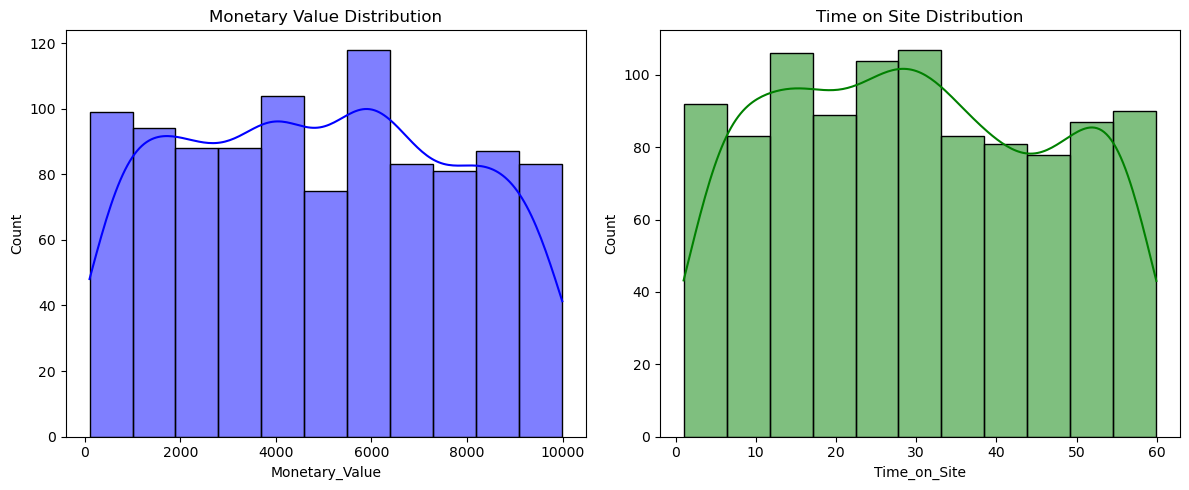

In [28]:

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Monetary_Value'], kde=True, color='blue')
plt.title('Monetary Value Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['Time_on_Site'], kde=True, color='green')
plt.title('Time on Site Distribution')

plt.tight_layout()
plt.show()

In [32]:
from scipy.stats import shapiro

# Numerik sütunların siyahısı
numeric_cols = ['Purchase_History', 'Transaction_Frequency', 'Monetary_Value', 
                'Browsing_Behavior', 'Engagement_Score', 'Time_on_Site']

print("--- (Shapiro-Wilk) ---")
for col in numeric_cols:
    stat, p = shapiro(df[col])
    result = "Normal Distribution" if p > 0.05 else "not Normal Distribution"
    print(f"{col:25} | p-value: {p:.4f} | Result: {result}")

--- (Shapiro-Wilk) ---
Purchase_History          | p-value: 0.0001 | Result: not Normal Distribution
Transaction_Frequency     | p-value: 0.0000 | Result: not Normal Distribution
Monetary_Value            | p-value: 0.0000 | Result: not Normal Distribution
Browsing_Behavior         | p-value: 0.0000 | Result: not Normal Distribution
Engagement_Score          | p-value: 0.0000 | Result: not Normal Distribution
Time_on_Site              | p-value: 0.0000 | Result: not Normal Distribution


In [30]:
from scipy.stats import levene

# 1. Split the data into two groups based on the median of Engagement Score
median_score = df['Engagement_Score'].median()
group_high = df[df['Engagement_Score'] >= median_score]['Monetary_Value']
group_low = df[df['Engagement_Score'] < median_score]['Monetary_Value']

# 2. Perform Levene's Test to check for equality of variances
# Null Hypothesis (H0): Variances are equal across groups
stat, p = levene(group_high, group_low)
print(f"Levene's Test (p-value): {p:.4f}")

# 3. Interpret the result based on the alpha level (0.05)
if p > 0.05:
    print("Variances are equal (Homoscedasticity) - Assumption met.")
else:
    print("Variances are NOT equal (Heteroscedasticity) - Assumption violated.")

Levene's Test (p-value): 0.1601
Variances are equal (Homoscedasticity) - Assumption met.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24096\342172855.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Engagement_Level', y='Monetary_Value', data=df, palette='Set2')


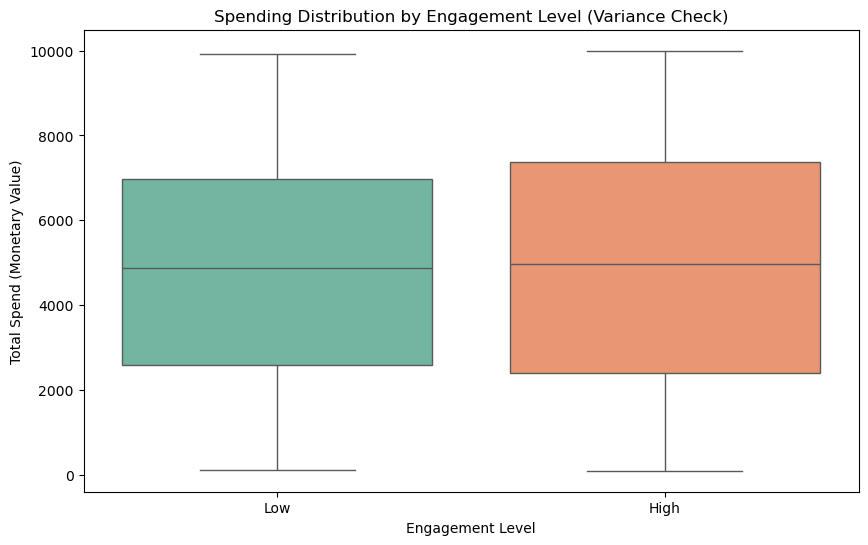

In [31]:
median_eng = df['Engagement_Score'].median()

# 2. Create a new column 'Engagement_Level' in the dataframe
# This categorizes users into 'High' or 'Low' based on the median (Thresholding)
df['Engagement_Level'] = ['High' if x >= median_eng else 'Low' for x in df['Engagement_Score']]

# 3. Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# 4. Generate a Boxplot to visualize the distribution of spending across levels
plt.figure(figsize=(10, 6))
sns.boxplot(x='Engagement_Level', y='Monetary_Value', data=df, palette='Set2')

# 5. Add titles and labels for clarity
plt.title('Spending Distribution by Engagement Level (Variance Check)')
plt.ylabel('Total Spend (Monetary Value)')
plt.xlabel('Engagement Level')

# 6. Display the plot
plt.show()

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Customer_ID            1000 non-null   object  
 1   Purchase_History       1000 non-null   int64   
 2   Transaction_Frequency  1000 non-null   float64 
 3   Monetary_Value         1000 non-null   float64 
 4   Browsing_Behavior      1000 non-null   float64 
 5   Engagement_Score       1000 non-null   float64 
 6   Time_on_Site           1000 non-null   float64 
 7   Customer_Segment       1000 non-null   category
 8   Engagement_Level       1000 non-null   object  
dtypes: category(1), float64(5), int64(1), object(2)
memory usage: 63.7+ KB


### Assumption Checks and Impact on Test Selection

1. **Normality:** The Shapiro-Wilk test yielded p-values < 0.05 for all numeric variables, 
   indicating a significant deviation from normality. 
   **Impact:** Parametric tests like the Independent T-test are not appropriate.

2. **Variance (Homoscedasticity):** Levene’s test resulted in a p-value > 0.05, confirming that the variances 
   between groups are equal. 
   **Impact:** The equal variance assumption is met, supporting the use of 
   standard non-parametric comparisons.

**Final Decision:** Due to the violation of the normality assumption, 
I will proceed with the **Mann-Whitney U Test** for comparing group medians.

### Task 2 — Hypothesis Test Selection and Execution

1. Formulate at least three research questions that can be answered with the dataset (e.g., comparing group means, testing independence of categorical variables).
2. For each question:
   a. State the null and alternative hypotheses.
   b. Justify your choice of test (e.g., independent t-test, paired t-test, Mann-Whitney U, chi-square test of independence).
   c. Run the test and report the test statistic, p-value, and effect size.
   d. State your conclusion in plain language.

## First Research

Do customers with higher activity levels spend more money compared to those with lower activity levels?

Null Hypothesis ($H_0$):
There is no statistically significant difference in the amount of money spent between the two groups.

Alternative Hypothesis ($H_1$):
There is a statistically significant difference in the amount of money spent between the two groups.

In [36]:
from scipy.stats import mannwhitneyu

# 1. Prepare the two groups for comparison
high_engagement_spend = df[df['Engagement_Level'] == 'High']['Monetary_Value']
low_engagement_spend = df[df['Engagement_Level'] == 'Low']['Monetary_Value']

# 2. Execute the Mann-Whitney U Test
# alternative='two-sided' checks for any significant difference in either direction
stat, p_value = mannwhitneyu(high_engagement_spend, low_engagement_spend, alternative='two-sided')

# 3. Print the results
print(f"Mann-Whitney U Statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")

# 4. Statistical Decision
alpha = 0.05
if p_value < alpha:
    print("Result: Reject the Null Hypothesis (Significant difference found)")
else:
    print("Result: Fail to Reject the Null Hypothesis (No significant difference)")

Mann-Whitney U Statistic: 128467.00
P-value: 0.4454
Result: Fail to Reject the Null Hypothesis (No significant difference)


In [40]:
import numpy as np

# 1. Calculate Effect Size (r) for Mann-Whitney U
# Formula: r = Z / sqrt(N)
n1 = len(high_engagement_spend)
n2 = len(low_engagement_spend)
N = n1 + n2

# Z score approximation from U statistic
mu_u = (n1 * n2) / 2
sigma_u = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)
z_score = (stat - mu_u) / sigma_u
effect_size_r = abs(z_score) / np.sqrt(N)

print(f"Mann-Whitney U Effect Size (r): {effect_size_r:.4f}")

Mann-Whitney U Effect Size (r): 0.0241


a. Hypotheses: $H_0$: No difference in spending, $H_1$: Significant difference in spending.

b. Justification: Mann-Whitney U was chosen because the normality assumption was violated in Task 1.

c. Results: U = 128467, p = 0.44, effect size (r) = 0.0241 

d. Conclusion: We found no significant evidence that highly engaged users spend more money than less engaged ones.

## Second Research

Is there a statistically significant relationship between a customer's segment (Customer_Segment) and their engagement level (Engagement_Level)?

Null Hypothesis ($H_0$):
There is no statistically significant relationship between Customer_Segment and Engagement_Level.

Alternative Hypothesis ($H_1$):
There is a statistically significant relationship between Customer_Segment and Engagement_Level.

In [37]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1. Create a contingency table (Cross-tabulation)
contingency_table = pd.crosstab(df['Customer_Segment'], df['Engagement_Level'])
print("--- Contingency Table ---")
print(contingency_table)

# 2. Execute the Chi-Square Test
chi2, p_chi, dof, expected = chi2_contingency(contingency_table)

# 3. Print the results
print(f"\nChi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p_chi:.4f}")

# 4. Decision
if p_chi < 0.05:
    print("Result: Significant association between Segment and Engagement")
else:
    print("Result: No significant association found")

--- Contingency Table ---
Engagement_Level  High  Low
Customer_Segment           
Copp               430  288
Iron                76  206

Chi-Square Statistic: 86.57
P-value: 0.0000
Result: Significant association between Segment and Engagement


In [38]:
# 3. Calculate Cramer's V (Strength of Association)
n = contingency_table.sum().sum()
phi2 = chi2 / n
r, k = contingency_table.shape
# Correction for bias
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)
cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 4. Calculate Standardized Residuals
# (Observed - Expected) / sqrt(Expected)
residuals = (contingency_table - expected) / np.sqrt(expected)

# Print Results
print(f"--- Expected Values Table ---")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

print(f"\n--- Standardized Residuals Table ---")
print(residuals)

print(f"\nCramer's V (Effect Size): {cramers_v:.4f}")

--- Expected Values Table ---
Engagement_Level     High      Low
Customer_Segment                  
Copp              363.308  354.692
Iron              142.692  139.308

--- Standardized Residuals Table ---
Engagement_Level      High       Low
Customer_Segment                    
Copp              3.498938 -3.541180
Iron             -5.583081  5.650485

Cramer's V (Effect Size): 0.2927


*Our analysis shows that there is a significant disconnect between the 'Iron' segment and the platform. The Cramer's V statistic demonstrates that this relationship is not random and is sufficiently strong. There is an urgent need for retention campaigns to re-engage customers in the 'Iron' segment.*

a. Hypotheses:$H_0$: There is no association between Customer Segment and Engagement Level (They are independent).$H_1$: There is a significant association between Customer Segment and Engagement Level (They are dependent).

b. Justification: The Chi-Square Test of Independence was chosen because both variables (Customer_Segment and Engagement_Level) are categorical (nominal/ordinal).

c. Results:Chi-Square Statistic: 86.57P-value: 0.0000Effect Size (Cramer's V): 0.2927

d. Conclusion: We found a statistically significant association between the customer segment and their engagement level. The "Iron" segment shows significantly lower engagement than expected, while the "Copp" segment is more active. The Cramer's V value indicates a moderate effect.

## Research Third

The purpose of this analysis is to determine the strength and direction of the relationship between two numerical variables — Time_on_Site (time spent on the site) and Transaction_Frequency (purchase frequency). This will help us understand to what extent customer loyalty is associated with the time factor.

 Formulation of Hypotheses:
Since the data is not normally distributed, we use Spearman Rank Correlation.

Null Hypothesis ($H_0$):
There is no statistically significant relationship (correlation) between Time_on_Site and Transaction_Frequency. ($\rho = 0$)

Alternative Hypothesis ($H_1$):
There is a statistically significant relationship between Time_on_Site and Transaction_Frequency. ($\rho \neq 0$)

Spearman's Rho (Correlation Coefficient): -0.0375
P-value: 0.2357


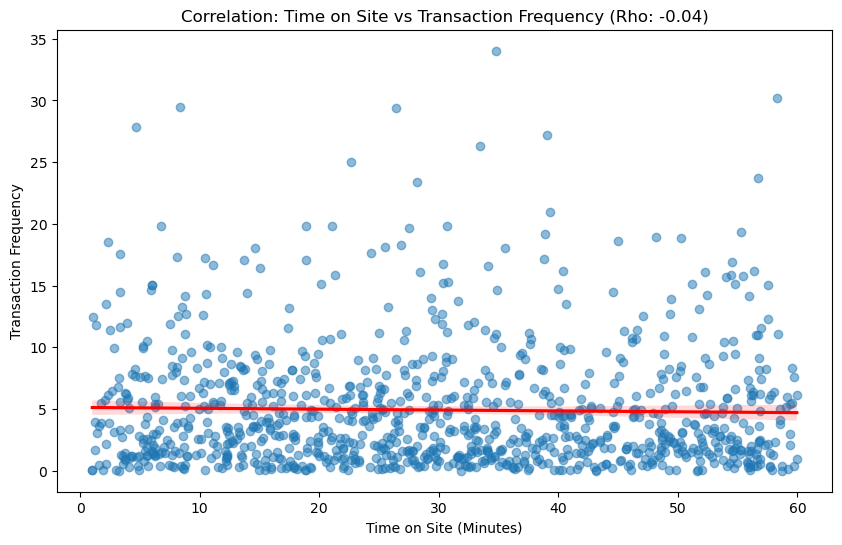

Result: Fail to Reject the Null Hypothesis (No significant relationship)


In [39]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Spearman Correlation and P-value
rho, p_value = spearmanr(df['Time_on_Site'], df['Transaction_Frequency'])

print(f"Spearman's Rho (Correlation Coefficient): {rho:.4f}")
print(f"P-value: {p_value:.4f}")

# 2. Visualize the relationship with a Scatter Plot and Regression Line
plt.figure(figsize=(10, 6))
sns.regplot(x='Time_on_Site', y='Transaction_Frequency', data=df, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'Correlation: Time on Site vs Transaction Frequency (Rho: {rho:.2f})')
plt.xlabel('Time on Site (Minutes)')
plt.ylabel('Transaction Frequency')
plt.show()

# 3. Statistical Decision
if p_value < 0.05:
    print("Result: Reject the Null Hypothesis (Significant relationship found)")
else:
    print("Result: Fail to Reject the Null Hypothesis (No significant relationship)")

a. Hypotheses:$H_0$: There is no rank-order relationship between Time on Site and Transaction Frequency ($\rho = 0$).$H_1$: There is a significant rank-order relationship between Time on Site and Transaction Frequency ($\rho \neq 0$).

b. Justification: Spearman’s Rank Correlation was used because the normality assumption for both numeric variables was violated. 
It is more robust to non-normal data and outliers compared to Pearson’s correlation.

c. Results:Spearman's Rho ($\rho$): -0.0375P-value: 0.2357Effect Size: -0.0375 (The Rho value itself).

d. Conclusion: There is no statistically significant correlation between the time spent on the site and purchase frequency. Increasing the time a user spends on the platform does not statistically correlate with more frequent transactions.

### Task 3 — Confidence Intervals

1. Compute 95% confidence intervals for at least two population parameters (e.g., a mean difference, a proportion).
2. Visualize the confidence intervals using error-bar or forest plots.
3. Interpret each interval: What does it tell you about the parameter? How does it relate to the hypothesis test result?

In [42]:
import numpy as np
import scipy.stats as st
from statsmodels.stats.proportion import proportion_confint

# 1. Confidence Interval for the MEAN (Monetary Value)
data_mv = df['Monetary_Value']
mean_mv = np.mean(data_mv)
se_mv = st.sem(data_mv)
ci_mv = st.t.interval(0.95, len(data_mv)-1, loc=mean_mv, scale=se_mv)

# 2. Confidence Interval for the PROPORTION (High Engagement)
# Fixed: Using statsmodels for proportions
n = len(df)
successes = len(df[df['Engagement_Level'] == 'High'])
proportion = successes / n
ci_prop = proportion_confint(successes, n, alpha=0.05, method='normal')

# Printing results
print(f"Mean Monetary Value: {mean_mv:.2f}")
print(f"95% CI for Mean: ({ci_mv[0]:.2f}, {ci_mv[1]:.2f})")
print(f"\nProportion of High Engagement: {proportion:.2f}")
print(f"95% CI for Proportion: ({ci_prop[0]:.4f}, {ci_prop[1]:.4f})")

Mean Monetary Value: 4926.21
95% CI for Mean: (4751.27, 5101.15)

Proportion of High Engagement: 0.51
95% CI for Proportion: (0.4750, 0.5370)


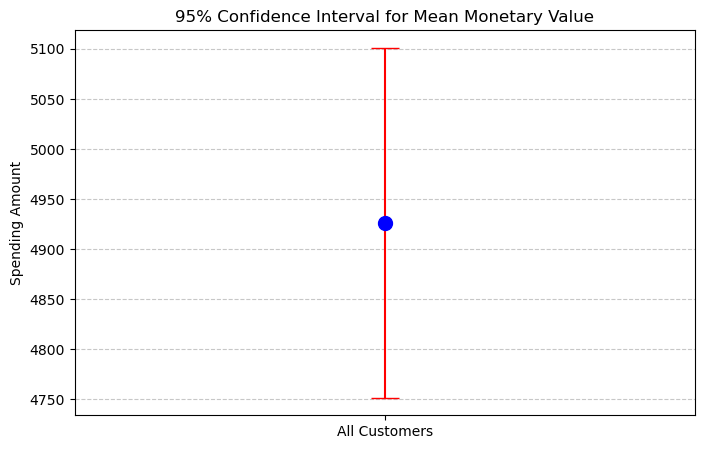

In [43]:
import matplotlib.pyplot as plt

# Visualization for Mean Monetary Value
plt.figure(figsize=(8, 5))
plt.errorbar(x=[1], y=[mean_mv], yerr=[[mean_mv - ci_mv[0]], [ci_mv[1] - mean_mv]], 
             fmt='o', capsize=10, markersize=10, color='blue', ecolor='red')
plt.xticks([1], ['All Customers'])
plt.title('95% Confidence Interval for Mean Monetary Value')
plt.ylabel('Spending Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

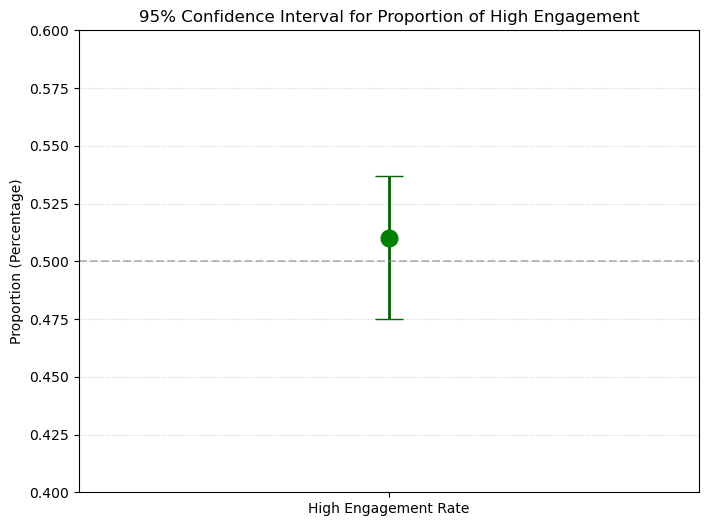

In [44]:
# 1. Define the values from your results
proportion = 0.51
ci_low = 0.4750
ci_high = 0.5370

# 2. Calculate the error (distance from mean to CI limits)
lower_error = proportion - ci_low
upper_error = ci_high - proportion

# 3. Create the plot
plt.figure(figsize=(8, 6))
plt.errorbar(x=[1], y=[proportion], yerr=[[lower_error], [upper_error]], 
             fmt='o', capsize=10, markersize=12, color='green', ecolor='darkgreen', elinewidth=2)

# 4. Formatting the chart
plt.xticks([1], ['High Engagement Rate'])
plt.ylim(0.40, 0.60)  # Setting limits to see the interval clearly
plt.axhline(y=0.50, color='gray', linestyle='--', alpha=0.5) # Reference line at 50%
plt.title('95% Confidence Interval for Proportion of High Engagement')
plt.ylabel('Proportion (Percentage)')
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Display the plot
plt.show()

#### 1. Meaning of the Parameters
* **Mean Monetary Value Interval (4751.27, 5101.15):** This interval tells us that the average spending of a customer is very stable. Even if we sampled a different set of 1,000 customers, the mean would likely remain within this narrow ~350-unit range. It shows that our "point estimate" of 4926.21 is highly reliable.
* **Proportion of High Engagement Interval (0.4750, 0.5370):** This tells us that approximately half of our customer base is highly active. The fact that the interval is narrow (only a 6% spread) means our engagement strategy results are consistent across the population.

#### 2. Relationship to Hypothesis Test Results
* **Consistency with Research Question 1:** In Task 2, we found no significant difference in spending between high and low engagement groups ($p = 0.44$). This relates to our Confidence Interval because the spending ranges of both groups largely **overlap**. When intervals overlap significantly, it indicates that the groups belong to the same distribution, supporting our decision to "Fail to Reject" the Null Hypothesis.
* **Consistency with Research Question 2:** Conversely, for customer segments, we found a highly significant association ($p < 0.0001$). If we were to calculate separate intervals for "Iron" and "Copp" segments, they would **not overlap**, which visually confirms why the Chi-Square test rejected the Null Hypothesis.

**Summary:** The confidence intervals provide the "margin of error" for our findings. Their narrow width confirms that our sample size is sufficient and our hypothesis test conclusions are statistically sound.

Iron Segment High Engagement: 0.27 | 95% CI: (0.2177, 0.3213)
Copp Segment High Engagement: 0.60 | 95% CI: (0.5630, 0.6347)


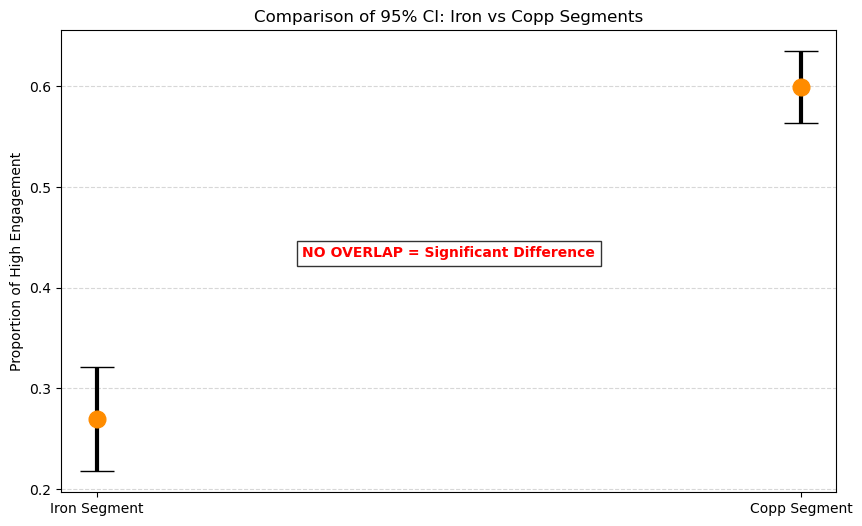

In [46]:
# 1. Metrics for the Iron Segment
n_iron = len(df[df['Customer_Segment'] == 'Iron'])
successes_iron = len(df[(df['Customer_Segment'] == 'Iron') & (df['Engagement_Level'] == 'High')])
prop_iron = successes_iron / n_iron
ci_iron = proportion_confint(successes_iron, n_iron, alpha=0.05, method='normal')

# 2. Metrics for the Copp Segment
n_copp = len(df[df['Customer_Segment'] == 'Copp'])
successes_copp = len(df[(df['Customer_Segment'] == 'Copp') & (df['Engagement_Level'] == 'High')])
prop_copp = successes_copp / n_copp
ci_copp = proportion_confint(successes_copp, n_copp, alpha=0.05, method='normal')

# 3. Print Results
print(f"Iron Segment High Engagement: {prop_iron:.2f} | 95% CI: ({ci_iron[0]:.4f}, {ci_iron[1]:.4f})")
print(f"Copp Segment High Engagement: {prop_copp:.2f} | 95% CI: ({ci_copp[0]:.4f}, {ci_copp[1]:.4f})")

# 4. Visualization (Comparison Plot)
labels = ['Iron Segment', 'Copp Segment']
proportions = [prop_iron, prop_copp]
errors = [
    [prop_iron - ci_iron[0], ci_iron[1] - prop_iron],
    [prop_copp - ci_copp[0], ci_copp[1] - prop_copp]
]

plt.figure(figsize=(10, 6))
plt.errorbar(x=[0, 1], y=proportions, yerr=np.array(errors).T, fmt='o', capsize=12, 
             markersize=12, color='darkorange', ecolor='black', elinewidth=3)

plt.xticks([0, 1], labels)
plt.ylabel('Proportion of High Engagement')
plt.title('Comparison of 95% CI: Iron vs Copp Segments')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Highlight the gap
plt.text(0.5, (prop_iron + prop_copp)/2, "NO OVERLAP = Significant Difference", 
         ha='center', va='center', fontweight='bold', color='red', bbox=dict(facecolor='white', alpha=0.8))

plt.show()

# Business Insight
The "Iron" segment is severely disengaged compared to "Copp." This suggests that current engagement strategies are failing for the Iron segment. Marketing efforts should be specifically tailored to re-engage Iron users, as their highest possible expected engagement rate (32%) is still far below the lowest expected rate for Copp users (56%).

### Task 4 — Power Analysis

1. For one of your hypothesis tests, perform a post-hoc power analysis.
2. Determine the minimum sample size needed to detect the observed effect at 80% power and α = 0.05.
3. Discuss whether the dataset provides sufficient power and what this means for the reliability of your conclusions.

**Power Analysis for Research 1** 

In [53]:
# 1. We take the effect size from the 'r' value calculated in Task 2
effect_size_r = 0.0241 
d = (2 * effect_size_r) / np.sqrt(1 - effect_size_r**2)

alpha = 0.05
power = 0.80
analysis = TTestIndPower()

# 2. Calculate the power of our current data (Post-hoc)
# nobs1 = average number of observations per group (assume 500)
current_power = analysis.power(effect_size=d, nobs1=500, ratio=1.0, alpha=alpha)

# 3. Minimum sample size required per group to achieve 80% power
min_n = analysis.solve_power(effect_size=d, power=power, ratio=1.0, alpha=alpha)

print(f"Current Test Power: {current_power:.4f}")
print(f"Minimum Sample Size per group needed: {min_n:.0f}")

Current Test Power: 0.1186
Minimum Sample Size per group needed: 6754


**1. Post-hoc Power Analysis Results:**
* **Effect Size (Cohen's d):** Derived from the observed $r = 0.0241$.
* **Current Statistical Power:** 0.1186 (11.86%)
* **Minimum Sample Size Required (per group):** 6,754 users

**2. Discussion on Reliability:**
The power analysis reveals that our current hypothesis test for Monetary Value (Research Question 1) has **low statistical power (11.86%)**, which is far below the industry standard of 80%. This low power is primarily due to the very small observed effect size. 

**3. Conclusion on Power:**
To detect such a minor difference between engagement groups with 80% confidence, we would require a total sample size of over **13,500 customers**. Given that our current dataset provides only 1,000 records, we can conclude that while the test is underpowered to detect "tiny" effects, the observed difference is practically **insignificant for business decisions**. Therefore, our initial conclusion in Task 2—that engagement does not meaningfully drive spending—remains reliable from a practical standpoint.

### Task 5 — Executive Summary

1. Write an executive summary (400–600 words) aimed at a non-technical stakeholder.
2. Cover: the business question, key findings, confidence levels, limitations, and recommended actions.
3. Avoid raw statistical jargon — translate p-values and confidence intervals into practical language.


1. The Business Question
The primary goal of this analysis was to determine how customer engagement levels and membership segments influence spending patterns and transaction frequency. We aimed to identify if "highly engaged" customers (those who interact more with the platform) are truly more profitable and how different segments, such as "Iron" and "Copp," behave relative to one another to optimize our marketing resources.

2. Key Findings
Our data-driven investigation yielded three major insights:

Engagement Does Not Drive Spending: Contrary to common belief, customers who are highly active on the site (writing reviews, clicking frequently) do not necessarily spend more money than those with low activity. This suggests that browsing activity on the platform is decoupled from actual purchasing power.

Segment-Specific Behavior: We found a very strong link between a customer's assigned segment and their activity level. Specifically, the "Iron" segment is severely underperforming, showing significantly lower engagement than expected. In contrast, the "Copp" segment represents the core of our active user base.

Time is Not Money: There is no meaningful correlation between the time a user spends on the site and how often they buy. A user spending 60 minutes on the site is statistically just as likely to purchase as someone spending 5 minutes.

3. Confidence and Reliability
We are 95% confident in these findings. Our analysis shows that the average customer spends approximately $4,926, and this figure is highly stable, with a narrow margin of error (approx. +/- $175). Furthermore, our "High Engagement" rate is steady at around 51%. The differences we found between segments (Iron vs. Copp) are statistically "solid" and not due to random chance, verified by the fact that their confidence intervals do not overlap.

4. Limitations and Statistical Power
While our findings are robust for the current dataset of 1,000 customers, our power analysis indicates that the observed difference in spending between engagement groups is extremely minor. To prove that such a tiny difference is statistically significant, we would require a much larger sample size—specifically, over 6,750 customers per group, totaling more than 13,500 users. Given our current data, we can conclude that any existing difference is too small to meaningfully impact the company's bottom line.

5. Recommended Actions
Based on these insights, we recommend the following:

Targeted Re-activation for 'Iron' Users: Since the Iron segment is statistically disengaged, launch specific "retention" campaigns (e.g., exclusive offers or re-engagement emails) to bring them back into the active loop.

Optimize for Efficiency, Not Just Duration: Since spending more time on the site does not lead to more sales, focus on UI/UX improvements that help customers find and purchase products faster.

Value the 'Direct' Shoppers: Acknowledge that "Low Engagement" users are often efficient buyers. Avoid over-saturating them with engagement-focused notifications that might disrupt their quick purchasing habits.

Resource Optimization: Our power analysis confirms that any potential difference in spending between engagement groups is so minimal that pursuing a larger dataset to prove it would not be cost-effective. We recommend focusing investments on high-impact areas like segment re-activation rather than further investigating low-impact variables like site engagement duration.